**Author:** Steve Landry Ndjock 

**Version:** 1.0

**Python version:**  3.x

In [1]:
%matplotlib inline

# Core libraries
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, f_regression
from sklearn.experimental import enable_iterative_imputer

from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)


# Data Preparation

In [2]:
df = pd.read_csv("cmi_internet_WT_outlier_New_features.csv")
df_original = pd.read_csv("dm2_25_26_dataset_tabular/DM2_project/cmi_internet.csv")

In [3]:
from sklearn.datasets import load_breast_cancer

X = df.values
y = np.array(df_original.loc[df.index, 'sii'])

In [4]:
df.head()

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,...,PCIAT-PCIAT_20,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec
0,0,5.0,0,3,51.0,0,16.877316,46.000,50.8,26.0,...,4,0,55.00,72.75,0,3,6.5,20.625,2.010,448.0
1,2,9.0,0,2,56.4,0,14.035590,48.000,46.0,22.0,...,0,0,46.00,64.00,2,0,11.0,20.625,2.010,271.0
2,2,10.0,1,0,71.0,0,16.648696,56.500,75.6,26.5,...,1,0,38.00,54.00,2,2,10.0,12.450,2.010,453.0
3,3,9.0,0,0,71.0,2,18.292347,56.000,81.6,26.0,...,1,2,31.00,45.00,3,0,7.0,20.625,2.009,577.0
4,1,18.0,1,2,65.0,2,17.937682,60.485,77.0,26.0,...,1,3,44.45,61.00,1,1,9.0,21.305,1.040,457.0


# Data Partitioning

In [5]:
from sklearn.model_selection import train_test_split, cross_val_score 

from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
                                                    random_state=100, stratify=y)

In [7]:
X_train.shape

(5922, 83)

# Classification

In [8]:
from sklearn.tree import DecisionTreeClassifier

In [9]:
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.6863672182821119
F1-score [0.80829596 0.38125666 0.42481203 0.43243243]
              precision    recall  f1-score   support

         0.0      0.793     0.824     0.808      1750
         1.0      0.387     0.376     0.381       476
         2.0      0.459     0.395     0.425       286
         3.0      0.727     0.308     0.432        26

    accuracy                          0.686      2538
   macro avg      0.592     0.476     0.512      2538
weighted avg      0.679     0.686     0.681      2538



# Feature Selection

## Variance Threshold

In [10]:
np.histogram(np.var(X_train, axis=0)[np.var(X_train, axis=0) < 3.14e04])

(array([76,  2,  0,  0,  0,  2,  0,  0,  0,  1], dtype=int64),
 array([7.65774114e-02, 1.18098408e+03, 2.36189158e+03, 3.54279908e+03,
        4.72370659e+03, 5.90461409e+03, 7.08552159e+03, 8.26642909e+03,
        9.44733659e+03, 1.06282441e+04, 1.18091516e+04]))

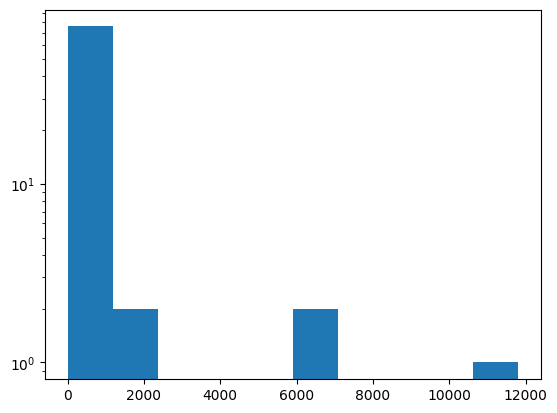

In [11]:
plt.hist(np.var(X_train, axis=0)[np.var(X_train, axis=0) < 3.14e04])
plt.yscale('log')
plt.show()

In [12]:
from sklearn.feature_selection import VarianceThreshold

In [13]:
(.8 * (1 - .8))

0.15999999999999998

In [14]:
sel = VarianceThreshold(threshold=(.8 * (1 - .8)))
X_train_sel = sel.fit_transform(X_train)

X_train_sel.shape

(5922, 77)

In [15]:
X_train.shape

(5922, 83)

In [16]:
X_test_sel = sel.transform(X_test)

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_sel, y_train)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.6828211189913318
F1-score [0.80627979 0.37632135 0.41444867 0.43243243]
              precision    recall  f1-score   support

         0.0      0.791     0.822     0.806      1750
         1.0      0.379     0.374     0.376       476
         2.0      0.454     0.381     0.414       286
         3.0      0.727     0.308     0.432        26

    accuracy                          0.683      2538
   macro avg      0.588     0.471     0.507      2538
weighted avg      0.675     0.683     0.678      2538



## Univariate Feature Selection

In [17]:
from sklearn.feature_selection import SelectKBest

In [18]:
sel = SelectKBest(k=10)
X_train_sel = sel.fit_transform(X_train, y_train)

X_train_sel.shape

(5922, 10)

In [19]:
sel.scores_

array([5.35530925e-01, 8.33114653e+01, 1.70857121e+01, 1.31473012e+00,
       1.10974061e+00, 2.23348461e+00, 1.65943230e+01, 1.17156754e+02,
       8.39481011e+01, 3.22326655e+01, 6.60108982e+00, 3.30595422e+00,
       2.20948984e+01, 1.50220134e+00, 2.73756094e-01, 2.23290182e+00,
       2.09640118e+00, 7.43588341e-01, 6.68581854e+01, 8.07577867e+00,
       1.20282331e+01, 6.93582707e+00, 1.23164896e+01, 7.34815419e+00,
       3.97083668e+01, 1.65673317e+01, 3.63706012e+00, 1.67620278e+01,
       5.14921430e+00, 1.04208432e+01, 1.50270941e+01, 5.95938449e+00,
       3.22295354e+00, 1.51040865e+00, 8.97981372e-01, 3.03874529e+01,
       4.55989347e+01, 1.24278851e+01, 1.94976081e+01, 9.42061219e+00,
       2.34705221e+00, 2.63064369e+01, 4.33747937e+01, 1.69013705e+01,
       6.32585755e+01, 2.69890249e+01, 4.46664102e+00, 1.10925408e+01,
       3.43844660e+01, 2.88170816e+01, 4.67119524e-01, 2.54410462e+00,
       3.72793609e-01, 6.49384278e+00, 2.82643503e+02, 3.81766241e+02,
      

In [20]:
X_test_sel = sel.transform(X_test)

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_sel, y_train)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.7415287628053585
F1-score [0.84916773 0.38378378 0.40493827 0.        ]
              precision    recall  f1-score   support

         0.0      0.769     0.947     0.849      1750
         1.0      0.538     0.298     0.384       476
         2.0      0.689     0.287     0.405       286
         3.0      0.000     0.000     0.000        26

    accuracy                          0.742      2538
   macro avg      0.499     0.383     0.409      2538
weighted avg      0.709     0.742     0.703      2538



c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

## Recursive Feature Elimination (RFE)

In [21]:
from sklearn.feature_selection import RFE

In [34]:
sel = RFE(DecisionTreeClassifier(), n_features_to_select=4)
X_train_sel = sel.fit_transform(X_train, y_train)
X_train_sel.shape

(5922, 4)

In [35]:
X_test_sel = sel.transform(X_test)

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_sel, y_train)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.6166272655634357
F1-score [0.76467361 0.25054945 0.20247934 0.44444444]
              precision    recall  f1-score   support

         0.0      0.735     0.797     0.765      1750
         1.0      0.263     0.239     0.251       476
         2.0      0.247     0.171     0.202       286
         3.0      0.800     0.308     0.444        26

    accuracy                          0.617      2538
   macro avg      0.511     0.379     0.416      2538
weighted avg      0.592     0.617     0.602      2538



## Select Form Model
Meta-transformer for selecting features based on importance weights.

In [36]:
from sklearn.feature_selection import SelectFromModel

In [37]:
sel = SelectFromModel(DecisionTreeClassifier())
X_train_sel = sel.fit_transform(X_train, y_train)
X_train_sel.shape

(5922, 32)

In [38]:
X_test_sel = sel.transform(X_test)

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_sel, y_train)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.6662726556343578
F1-score [0.79558324 0.35232068 0.39642857 0.44444444]
              precision    recall  f1-score   support

         0.0      0.788     0.803     0.796      1750
         1.0      0.354     0.351     0.352       476
         2.0      0.405     0.388     0.396       286
         3.0      0.800     0.308     0.444        26

    accuracy                          0.666      2538
   macro avg      0.587     0.462     0.497      2538
weighted avg      0.664     0.666     0.664      2538



# Feature Projection

## Principal Component Analysis

In [39]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler   

In [40]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [42]:
X_train_pca.shape

(5922, 2)

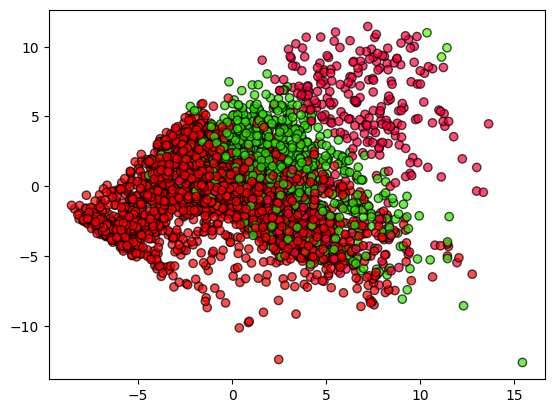

In [43]:
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, 
            cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [44]:
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_pca, y_train)

y_pred = clf.predict(X_test_pca)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.7147360126083531
F1-score [0.82573875 0.41630901 0.47540984 0.51428571]
              precision    recall  f1-score   support

         0.0       0.80      0.85      0.83      1750
         1.0       0.43      0.41      0.42       476
         2.0       0.57      0.41      0.48       286
         3.0       1.00      0.35      0.51        26

    accuracy                           0.71      2538
   macro avg       0.70      0.50      0.56      2538
weighted avg       0.71      0.71      0.71      2538



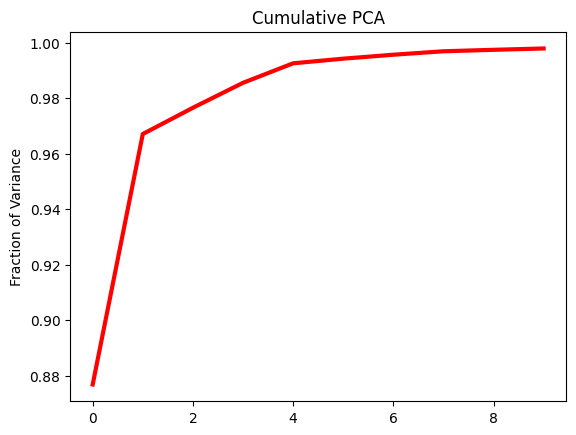

In [45]:
plt.plot(np.cumsum(PCA(n_components=10).fit(X).explained_variance_ratio_), lw=3, color='r', ms=2)
plt.title("Cumulative PCA")
plt.ylabel("Fraction of Variance")
plt.show()

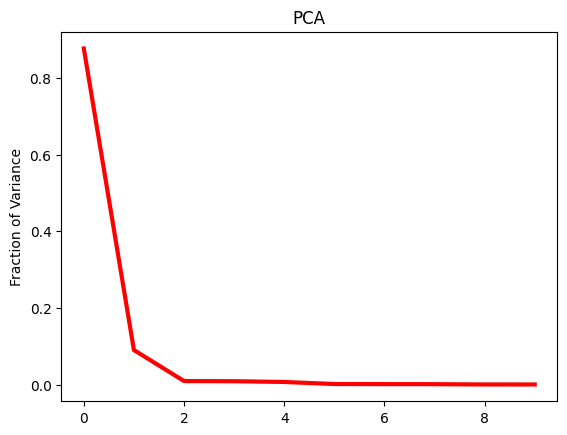

In [46]:
plt.plot(PCA(n_components=10).fit(X).explained_variance_ratio_, lw=3, color='r', ms=2)
plt.title("PCA")
plt.ylabel("Fraction of Variance")
plt.show()

# Random Subspace Projection

In [47]:
from sklearn import random_projection

In [48]:
rsp = random_projection.GaussianRandomProjection(n_components=2, random_state=None)
X_train_rsp = rsp.fit_transform(X_train_scaled)
X_test_rsp = rsp.transform(X_test_scaled)
X_train_rsp.shape

(5922, 2)

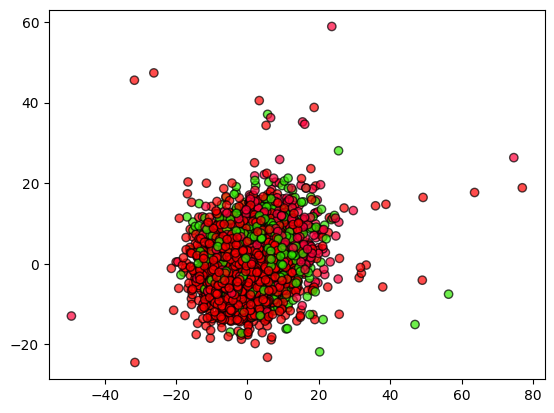

In [49]:
plt.scatter(X_train_rsp[:, 0], X_train_rsp[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [50]:
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_rsp, y_train)

y_pred = clf.predict(X_test_rsp)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.6126871552403468
F1-score [0.76386601 0.21640091 0.23506744 0.43243243]
              precision    recall  f1-score   support

         0.0       0.74      0.79      0.76      1750
         1.0       0.24      0.20      0.22       476
         2.0       0.26      0.21      0.24       286
         3.0       0.73      0.31      0.43        26

    accuracy                           0.61      2538
   macro avg       0.49      0.38      0.41      2538
weighted avg       0.59      0.61      0.60      2538



## Multi Dimensional Scaling

In [51]:
from sklearn.manifold import MDS

In [ ]:
mds = MDS(n_components=2, normalized_stress='auto') #, normalized_stress='auto') # shoudl run as sammon mapping
X_train_mds = mds.fit_transform(X_train_scaled)
X_train_mds.shape

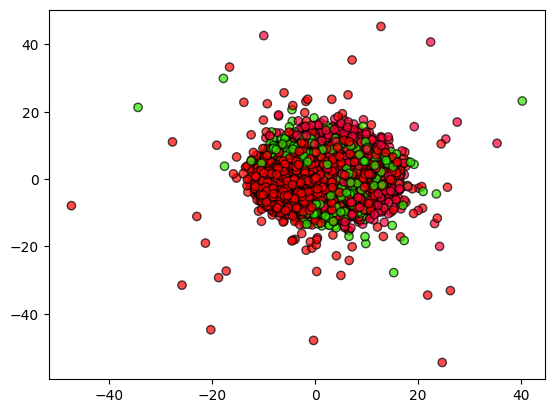

In [53]:
plt.scatter(X_train_mds[:, 0], X_train_mds[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [54]:
#X_test_mds = mds.transform(X_test) # no transform

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_mds, y_train)

y_pred = clf.predict(X_train_mds)

print('Accuracy %s' % accuracy_score(y_train, y_pred))
print('F1-score %s' % f1_score(y_train, y_pred, average=None))
print(classification_report(y_train, y_pred))

Accuracy 0.8569739952718676
F1-score [0.9162143  0.72369053 0.69230769 0.55913978]
              precision    recall  f1-score   support

         0.0       0.88      0.95      0.92      4083
         1.0       0.78      0.68      0.72      1111
         2.0       0.78      0.62      0.69       666
         3.0       0.84      0.42      0.56        62

    accuracy                           0.86      5922
   macro avg       0.82      0.67      0.72      5922
weighted avg       0.85      0.86      0.85      5922



## IsoMap

In [55]:
from sklearn.manifold import Isomap

In [ ]:
iso = Isomap(n_components=2, n_neighbors=5) # n_neighbors=5 is the default, but it is important to specify it here to avoid a warning about future changes in the default value
X_train_iso = iso.fit_transform(X_train_scaled)
X_test_iso = iso.transform(X_test_scaled)
X_train_iso.shape

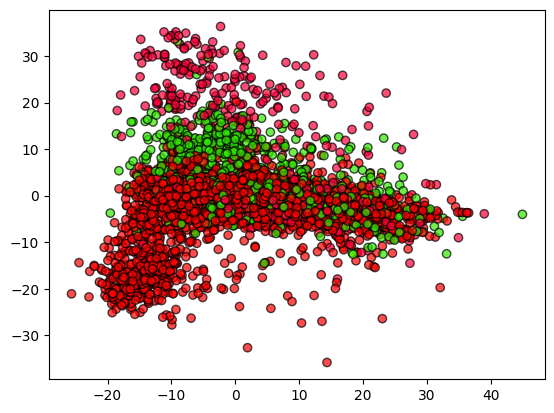

In [57]:
plt.scatter(X_train_iso[:, 0], X_train_iso[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [58]:
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_iso, y_train)

y_pred = clf.predict(X_test_iso)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.6910953506698188
F1-score [0.81002203 0.34392114 0.47580645 0.45714286]
              precision    recall  f1-score   support

         0.0       0.78      0.84      0.81      1750
         1.0       0.36      0.33      0.34       476
         2.0       0.56      0.41      0.48       286
         3.0       0.89      0.31      0.46        26

    accuracy                           0.69      2538
   macro avg       0.65      0.47      0.52      2538
weighted avg       0.68      0.69      0.68      2538



## t-SNE

In [59]:
from sklearn.manifold import TSNE

In [60]:
tsne = TSNE(n_components=2)
X_train_tsne = tsne.fit_transform(X_train_scaled)
X_train_tsne.shape

(5922, 2)

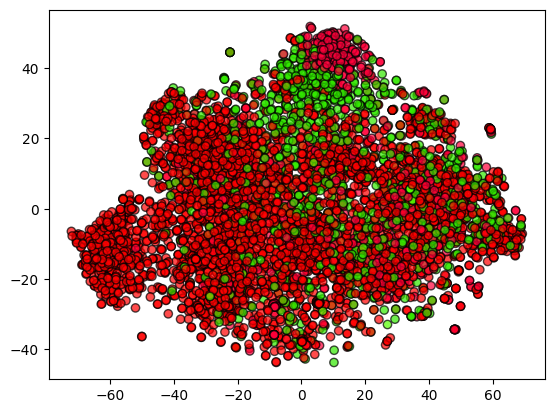

In [61]:
plt.scatter(X_train_tsne[:, 0], X_train_tsne[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [62]:
#X_test_mds = mds.transform(X_test) # no transform

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_tsne, y_train)

y_pred = clf.predict(X_train_tsne)

print('Accuracy %s' % accuracy_score(y_train, y_pred))
print('F1-score %s' % f1_score(y_train, y_pred, average=None))
print(classification_report(y_train, y_pred))

Accuracy 0.8699763593380615
F1-score [0.92298592 0.75620028 0.71698113 0.56818182]
              precision    recall  f1-score   support

         0.0       0.89      0.96      0.92      4083
         1.0       0.79      0.73      0.76      1111
         2.0       0.84      0.63      0.72       666
         3.0       0.96      0.40      0.57        62

    accuracy                           0.87      5922
   macro avg       0.87      0.68      0.74      5922
weighted avg       0.87      0.87      0.86      5922

